# Eixo Logística — KPIs & Análises

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

BASE      = Path("..").resolve()
DATA_FILE = BASE / "data" / "sales_data_clean.csv"
OUT_DIR   = BASE / "Logistica" / "output_logistics"
OUT_DIR.mkdir(exist_ok=True)

print(f"Data: {DATA_FILE}")
print(f"Output: {OUT_DIR}")

Data: /Users/ruimartins/Documents/Hackathons/PWC_Crack_the_data/02. Dados/sales_data_clean.csv
Output: /Users/ruimartins/Documents/Hackathons/PWC_Crack_the_data/03. Análise/output_logistics


## 1. Load & Prepare Data

In [2]:
df_full = pd.read_csv(DATA_FILE, parse_dates=["Order_Date", "Due_Date"])
print(f"Full dataset : {len(df_full):,} rows")

df = df_full[df_full["Has_Shipping"]].copy()
print(f"Shipping subset : {len(df):,} rows ({len(df)/len(df_full)*100:.1f}% of total)")

# ── derived columns ────────────────────────────────────────────────────────
df["Gross_Profit"]        = df["Sales_Price"] - df["Production_Cost"]
df["Net_Profit"]          = df["Gross_Profit"] - df["Shipping_Cost"]
df["Gross_Margin_Pct"]    = df["Gross_Profit"] / df["Sales_Price"] * 100
df["Net_Margin_Pct"]      = df["Net_Profit"]   / df["Sales_Price"] * 100
df["Shipping_Cost_Ratio"] = df["Shipping_Cost"] / df["Sales_Price"] * 100
df["Lead_Time_Days"]      = (df["Due_Date"] - df["Order_Date"]).dt.days

df.head(3)

Full dataset : 147,511 rows
Shipping subset : 26,480 rows (18.0% of total)


,Region,Source_File,Sales_Order_ID,Year_Original,Year,Order_Date,Due_Date,Country,Shop_ID,Year_Opened,Product_Category,Main_Category,Subcategory,Product_ID,Product_Name,Shipping_Company,Sales_Price,Production_Cost,Shipping_Cost,Has_Shipping,Gross_Profit,Net_Profit,Gross_Margin_Pct,Net_Margin_Pct,Shipping_Cost_Ratio,Lead_Time_Days
15,Asia,Asia_SalesData.xlsx,S00859525,2020,2020,2020-01-01,2020-01-04,China,27.00,NaN,Clothing_Top base layers,Clothing,Top base layers,CTFTLB350,Fleece Top L Black,SnowLogistics,116.73,71.54,8.77,True,45.19,36.42,38.71,31.20,7.51,3
16,Asia,Asia_SalesData.xlsx,S00859526,2020,2020,2020-01-01,2020-01-08,Japan,27.00,NaN,Technical equipment_Poles,Technical equipment,Poles,TPPPP498,Plus Powder Poles,SnowLogistics,86.67,41.17,7.25,True,45.50,38.25,52.50,44.13,8.37,7
24,Asia,Asia_SalesData.xlsx,S00859548,2020,2020,2020-01-02,2020-01-09,Japan,27.00,NaN,Accessories_Ski socks,Accessories,Ski socks,ASMWSG727,Merino Wool Socks Green,SnowLogistics,14.03,9.60,2.01,True,4.43,2.42,31.58,17.25,14.33,7


## 2. KPI Summary (L01–L06)

| ID  | KPI | Fórmula |
|-----|-----|---------|
| L01 | Shipping Cost Total | `SUM(Shipping_Cost)` |
| L02 | Shipping Cost médio/pedido | `AVG(Shipping_Cost)` |
| L03 | Shipping Cost Ratio | `Shipping_Cost / Sales_Price × 100` |
| L04 | Net Margin % (c/ shipping) | `(GP − Shipping_Cost) / Revenue × 100` |
| L05 | Δ Margin (gross vs net) | `Gross Margin % − Net Margin %` |
| L06 | Lead Time médio | `AVG(Due_Date − Order_Date)` |

In [3]:
l01 = df["Shipping_Cost"].sum()
l02 = df["Shipping_Cost"].mean()
l03 = df["Shipping_Cost_Ratio"].mean()
l04_net   = df["Net_Margin_Pct"].mean()
l04_gross = df["Gross_Margin_Pct"].mean()
l05 = l04_gross - l04_net
l06_subset = df["Lead_Time_Days"].notna().sum()
l06 = df.loc[df["Lead_Time_Days"].notna(), "Lead_Time_Days"].mean()

summary = pd.DataFrame({
    "KPI": ["L01 Shipping Cost Total (€)", "L02 Avg Shipping Cost/order (€)",
            "L03 Shipping Cost Ratio (%)", "L04 Gross Margin % (w/ shipping)",
            "L04 Net Margin % (w/ shipping)", "L05 Δ Margin (p.p.)",
            f"L06 Avg Lead Time (days) — {l06_subset:,} orders with Due_Date"],
    "Value": [f"€{l01:,.2f}", f"€{l02:.2f}", f"{l03:.2f}%",
              f"{l04_gross:.2f}%", f"{l04_net:.2f}%", f"{l05:.2f} p.p.",
              f"{l06:.1f} days"]
})
summary

,KPI,Value
0,L01 Shipping Cost Total (€),"€532,545.18"
1,L02 Avg Shipping Cost/order (€),€20.11
2,L03 Shipping Cost Ratio (%),10.00%
3,L04 Gross Margin % (w/ shipping),44.96%
4,L04 Net Margin % (w/ shipping),34.96%
5,L05 Δ Margin (p.p.),10.00 p.p.
6,"L06 Avg Lead Time (days) — 26,480 orders with ...",5.0 days


## 3. Helper: generic KPI table builder

In [ ]:
def kpi_table(group_cols: list) -> pd.DataFrame:
    """Return L01-L06 KPIs aggregated by any grouping."""
    g = df.groupby(group_cols, observed=True)
    glt = df[df["Lead_Time_Days"].notna()].groupby(group_cols, observed=True)
    t = pd.DataFrame({
        "L01_Shipping_Cost_Total":   g["Shipping_Cost"].sum(),
        "L02_Avg_Shipping_Cost":     g["Shipping_Cost"].mean(),
        "L03_Shipping_Cost_Ratio":   g["Shipping_Cost_Ratio"].mean(),
        "L04_Gross_Margin_Pct":      g["Gross_Margin_Pct"].mean(),
        "L04_Net_Margin_Pct":        g["Net_Margin_Pct"].mean(),
        "L05_Delta_Margin_pp":       g["Gross_Margin_Pct"].mean() - g["Net_Margin_Pct"].mean(),
        "L06_Avg_Lead_Time_Days":    glt["Lead_Time_Days"].mean(),
        "N_Orders":                  g["Sales_Order_ID"].count(),
    }).reset_index()
    return t

## 4. L-A1 — Carrier Profile by Country (L01, L02, L03)

In [5]:
la1 = kpi_table(["Country", "Shipping_Company"])

# flag carriers with Shipping_Cost_Ratio > 1.5× country median
country_median = (
    df.groupby("Country", observed=True)["Shipping_Cost_Ratio"]
    .median()
    .rename("Country_Median_Ratio")
)
la1 = la1.merge(country_median, on="Country")
la1["Flag_High_Ratio"] = la1["L03_Shipping_Cost_Ratio"] > 1.5 * la1["Country_Median_Ratio"]

la1_display = la1.sort_values(["Country", "L01_Shipping_Cost_Total"], ascending=[True, False])
la1_display[["Country","Shipping_Company","N_Orders",
             "L01_Shipping_Cost_Total","L02_Avg_Shipping_Cost",
             "L03_Shipping_Cost_Ratio","Flag_High_Ratio"]]

,Country,Shipping_Company,N_Orders,L01_Shipping_Cost_Total,L02_Avg_Shipping_Cost,L03_Shipping_Cost_Ratio,Flag_High_Ratio
2,Andorra,SafeTrans,620,"12,027.56",19.40,10.22,False
0,Andorra,FastDelivery,585,"11,659.68",19.93,9.96,False
1,Andorra,QuickMove,588,"11,438.83",19.45,9.88,False
4,Austria,QuickMove,619,"12,699.12",20.52,9.89,False
3,Austria,FastDelivery,557,"11,215.22",20.14,10.01,False
5,Austria,SafeTrans,564,"11,019.66",19.54,10.11,False
7,Canada,SafeTrans,2723,"54,567.41",20.04,9.97,False
6,Canada,QuickMove,2573,"54,324.31",21.11,9.96,False
8,China,SnowLogistics,2713,"54,371.18",20.04,10.02,False
11,France,SafeTrans,608,"12,871.05",21.17,10.24,False


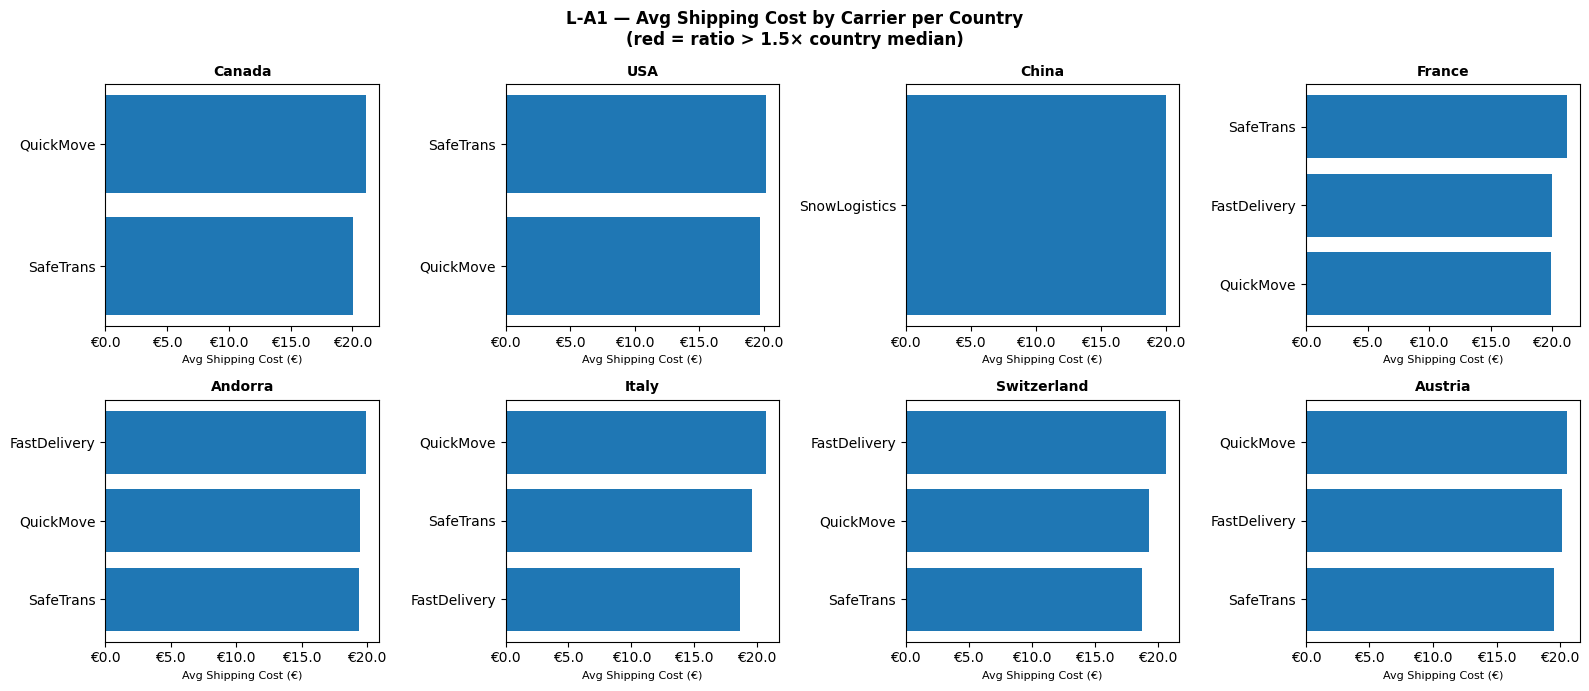

In [6]:
# Chart: avg shipping cost per carrier, facetted by top countries
top_countries = df["Country"].value_counts().head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.flatten()

for ax, country in zip(axes, top_countries):
    sub = la1[la1["Country"] == country].sort_values("L02_Avg_Shipping_Cost", ascending=True)
    colors = ["#d62728" if f else "#1f77b4" for f in sub["Flag_High_Ratio"]]
    ax.barh(sub["Shipping_Company"], sub["L02_Avg_Shipping_Cost"], color=colors)
    ax.set_title(country, fontsize=10, fontweight="bold")
    ax.set_xlabel("Avg Shipping Cost (€)", fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("€%.1f"))

fig.suptitle("L-A1 — Avg Shipping Cost by Carrier per Country\n(red = ratio > 1.5× country median)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "LA1_carrier_country.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
la1.to_csv(OUT_DIR / "LA1_carrier_country.csv", index=False)
print("Saved LA1_carrier_country.csv")

Saved LA1_carrier_country.csv


## 5. L-A2 — Shipping Impact on Margin by Country (L03, L04, L05)

In [8]:
la2 = kpi_table(["Country"]).sort_values("L05_Delta_Margin_pp", ascending=False)
la2["Flag_High_Erosion"] = la2["L05_Delta_Margin_pp"] > 2.0

la2[["Country","N_Orders","L04_Gross_Margin_Pct","L04_Net_Margin_Pct",
     "L05_Delta_Margin_pp","L03_Shipping_Cost_Ratio","Flag_High_Erosion"]]

,Country,N_Orders,L04_Gross_Margin_Pct,L04_Net_Margin_Pct,L05_Delta_Margin_pp,L03_Shipping_Cost_Ratio,Flag_High_Erosion
4,France,1797,45.20,35.10,10.10,10.10,True
6,Japan,1549,45.55,35.45,10.10,10.10,True
7,South Korea,1034,44.90,34.85,10.05,10.05,True
0,Andorra,1793,45.03,35.00,10.02,10.02,True
3,China,2713,44.89,34.87,10.02,10.02,True
1,Austria,1740,44.83,34.83,10.00,10.00,True
8,Spain,1732,44.91,34.93,9.98,9.98,True
5,Italy,1773,44.49,34.51,9.98,9.98,True
10,USA,5296,45.14,35.16,9.98,9.98,True
2,Canada,5296,44.79,34.83,9.96,9.96,True


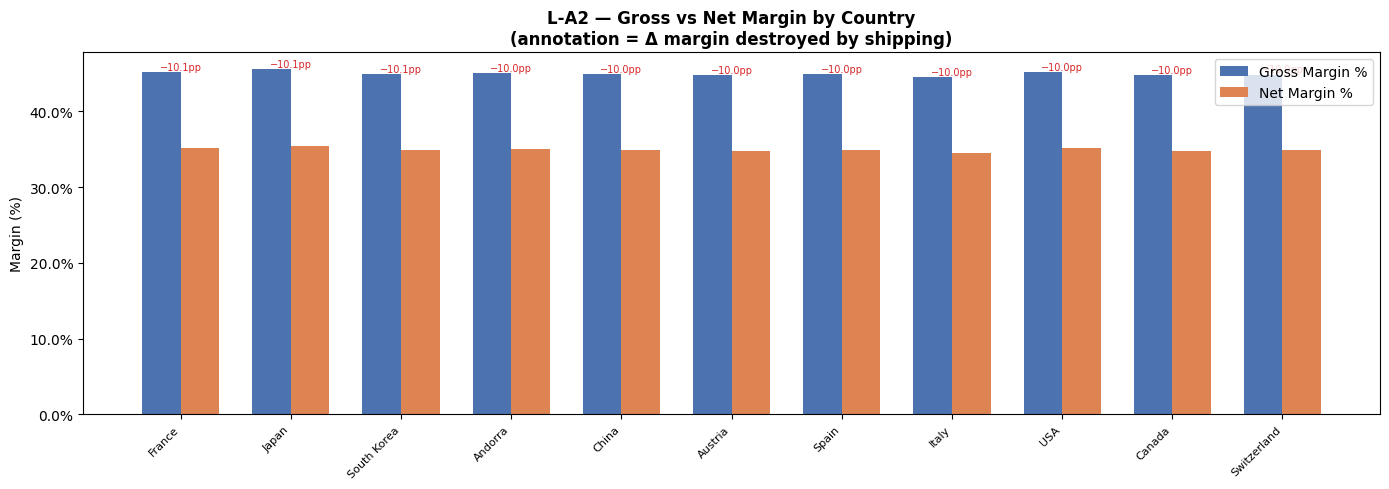

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(la2))
w = 0.35
bars_gross = ax.bar(x - w/2, la2["L04_Gross_Margin_Pct"], w, label="Gross Margin %", color="#4c72b0")
bars_net   = ax.bar(x + w/2, la2["L04_Net_Margin_Pct"],   w, label="Net Margin %",   color="#dd8452")

# annotate delta
for i, (gm, nm) in enumerate(zip(la2["L04_Gross_Margin_Pct"], la2["L04_Net_Margin_Pct"])):
    delta = gm - nm
    ax.annotate(f"−{delta:.1f}pp", xy=(x[i], max(gm, nm) + 0.3),
                ha="center", fontsize=7, color="#d62728")

ax.set_xticks(x)
ax.set_xticklabels(la2["Country"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Margin (%)")
ax.set_title("L-A2 — Gross vs Net Margin by Country\n(annotation = Δ margin destroyed by shipping)",
             fontweight="bold")
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=1))
plt.tight_layout()
plt.savefig(OUT_DIR / "LA2_margin_by_country.png", dpi=150, bbox_inches="tight")
plt.show()

la2.to_csv(OUT_DIR / "LA2_margin_by_country.csv", index=False)

## 6. L-A3 — Shipping Cost by Product Category (L02)

In [10]:
la3_main = kpi_table(["Main_Category"]).sort_values("L02_Avg_Shipping_Cost", ascending=False)
la3_sub  = kpi_table(["Main_Category", "Subcategory"]).sort_values("L02_Avg_Shipping_Cost", ascending=False)
la3_sub["Flag_High_Shipping"] = la3_sub["L02_Avg_Shipping_Cost"] > 1.5 * l02

print("By Main Category:")
display(la3_main[["Main_Category","N_Orders","L02_Avg_Shipping_Cost","L03_Shipping_Cost_Ratio"]])

print("\nTop 15 Subcategories by Avg Shipping Cost:")
display(la3_sub.head(15)[["Main_Category","Subcategory","N_Orders",
                           "L02_Avg_Shipping_Cost","L03_Shipping_Cost_Ratio","Flag_High_Shipping"]])

By Main Category:


,Main_Category,N_Orders,L02_Avg_Shipping_Cost,L03_Shipping_Cost_Ratio
2,Technical equipment,5600,52.24,9.96
1,Clothing,9567,17.61,10.03
0,Accessories,11312,6.32,10.00



Top 15 Subcategories by Avg Shipping Cost:


,Main_Category,Subcategory,N_Orders,L02_Avg_Shipping_Cost,L03_Shipping_Cost_Ratio,Flag_High_Shipping
13,Technical equipment,Skis,1918,79.74,9.95,True
11,Technical equipment,Boots,1827,59.52,9.98,True
9,Clothing,Suits,1874,27.23,9.98,False
7,Clothing,Jackets,1915,19.97,10.01,False
8,Clothing,Outerwear pants,1973,16.87,10.13,False
12,Technical equipment,Poles,1855,16.64,9.96,False
6,Clothing,Bottom base layers,1870,16.30,9.98,False
3,Accessories,Helmets,1919,13.02,10.01,False
1,Accessories,Goggles,1788,11.54,10.03,False
10,Clothing,Top base layers,1935,7.96,10.04,False


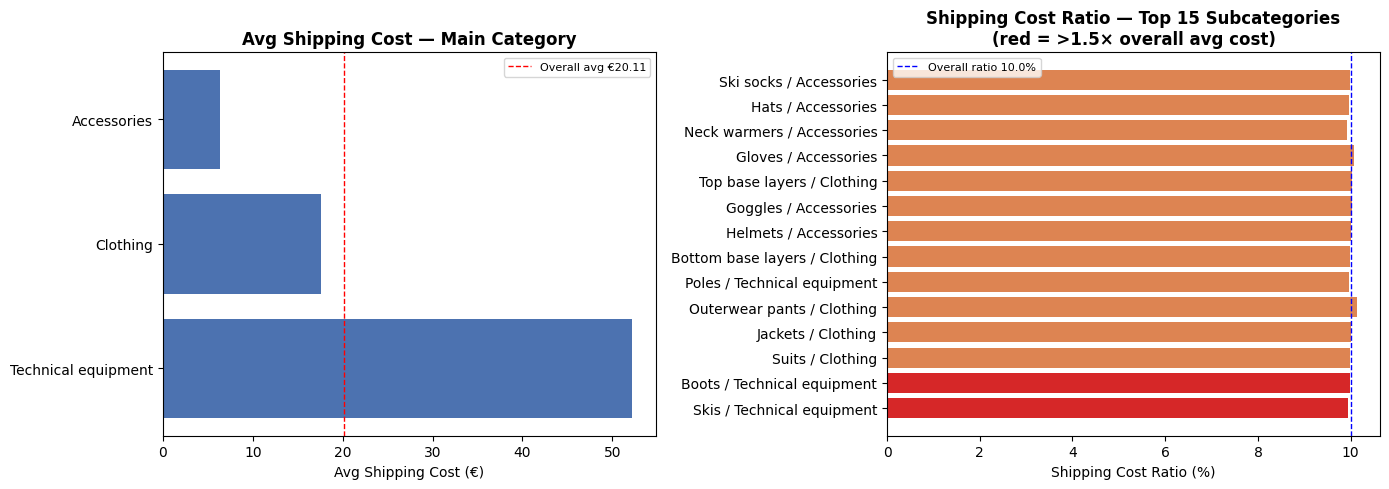

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: main category avg shipping cost
ax = axes[0]
ax.barh(la3_main["Main_Category"], la3_main["L02_Avg_Shipping_Cost"], color="#4c72b0")
ax.axvline(l02, color="red", linestyle="--", linewidth=1, label=f"Overall avg €{l02:.2f}")
ax.set_xlabel("Avg Shipping Cost (€)")
ax.set_title("Avg Shipping Cost — Main Category", fontweight="bold")
ax.legend(fontsize=8)

# right: subcategory shipping cost ratio (top 15)
ax2 = axes[1]
top15 = la3_sub.head(15)
colors = ["#d62728" if f else "#dd8452" for f in top15["Flag_High_Shipping"]]
ax2.barh(top15["Subcategory"] + " / " + top15["Main_Category"],
         top15["L03_Shipping_Cost_Ratio"], color=colors)
ax2.axvline(l03, color="blue", linestyle="--", linewidth=1, label=f"Overall ratio {l03:.1f}%")
ax2.set_xlabel("Shipping Cost Ratio (%)")
ax2.set_title("Shipping Cost Ratio — Top 15 Subcategories\n(red = >1.5× overall avg cost)", fontweight="bold")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / "LA3_shipping_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

la3_main.to_csv(OUT_DIR / "LA3_main_category.csv", index=False)
la3_sub.to_csv(OUT_DIR  / "LA3_subcategory.csv",   index=False)

## 7. L-A4 / L07 — Consolidatable Orders (same destination, Due_Date gap < 5 days)

In [12]:
df_due = df[df["Due_Date"].notna()].copy().sort_values(["Country", "Shop_ID", "Due_Date"])

records = []
for (country, shop), grp in df_due.groupby(["Country", "Shop_ID"], observed=True):
    grp = grp.sort_values("Due_Date").reset_index(drop=True)
    if len(grp) < 2:
        continue
    dates = grp["Due_Date"].values
    group_id = 0
    assigned = np.zeros(len(grp), dtype=int)
    window_start = dates[0]
    for i in range(1, len(grp)):
        delta = (dates[i] - window_start) / np.timedelta64(1, "D")
        if delta < 5:
            assigned[i] = group_id
        else:
            group_id += 1
            assigned[i] = group_id
            window_start = dates[i]
    grp["_group"] = assigned
    sizes = grp.groupby("_group").size()
    multi = sizes[sizes >= 2].index
    if not len(multi):
        continue
    sub = grp[grp["_group"].isin(multi)].copy()
    sub["Country"] = country
    sub["Shop_ID"]  = shop
    records.append(sub)

df_consol = pd.concat(records, ignore_index=True) if records else pd.DataFrame()

l07_total = len(df_consol)
total_saveable     = df_consol["Shipping_Cost"].sum() * 0.5 if l07_total else 0
total_saveable_pct = total_saveable / l01 * 100 if l07_total else 0

print(f"L07  Consolidatable orders : {l07_total:,}")
print(f"     Estimated saving (assume 50% reduction when consolidated) : "
      f"€{total_saveable:,.2f}  ({total_saveable_pct:.1f}% of total shipping spend)")

if l07_total:
    l07_by_country = (
        df_consol.groupby("Country", observed=True)
        .agg(N_Consolidatable=("Sales_Order_ID","count"),
             Saveable_EUR=("Shipping_Cost", lambda x: x.sum() * 0.5))
        .reset_index()
        .sort_values("N_Consolidatable", ascending=False)
    )
    display(l07_by_country)

L07  Consolidatable orders : 26,291
     Estimated saving (assume 50% reduction when consolidated) : €264,150.51  (49.6% of total shipping spend)


,Country,N_Consolidatable,Saveable_EUR
2,Canada,5296,"54,445.86"
10,USA,5296,"52,846.10"
3,China,2707,"27,125.43"
4,France,1781,"18,092.57"
0,Andorra,1774,"17,438.86"
5,Italy,1755,"17,236.57"
9,Switzerland,1745,"16,915.70"
1,Austria,1723,"17,155.73"
8,Spain,1708,"17,381.40"
6,Japan,1519,"15,330.88"


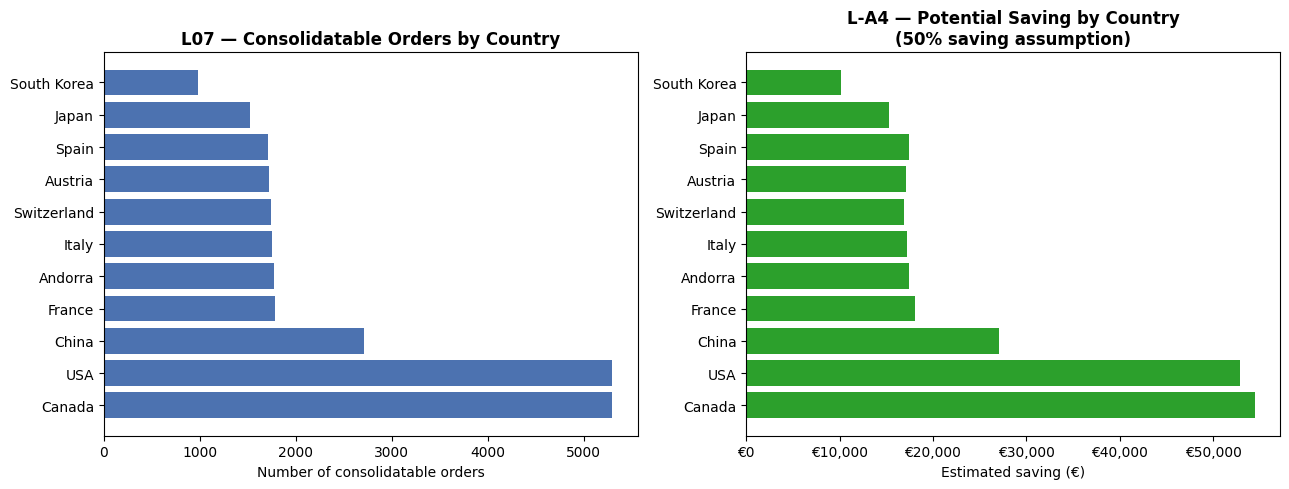

In [13]:
if l07_total:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].barh(l07_by_country["Country"], l07_by_country["N_Consolidatable"], color="#4c72b0")
    axes[0].set_xlabel("Number of consolidatable orders")
    axes[0].set_title("L07 — Consolidatable Orders by Country", fontweight="bold")

    axes[1].barh(l07_by_country["Country"], l07_by_country["Saveable_EUR"], color="#2ca02c")
    axes[1].set_xlabel("Estimated saving (€)")
    axes[1].set_title("L-A4 — Potential Saving by Country\n(50% saving assumption)", fontweight="bold")
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))

    plt.tight_layout()
    plt.savefig(OUT_DIR / "LA4_consolidation.png", dpi=150, bbox_inches="tight")
    plt.show()

    df_consol.to_csv(OUT_DIR / "LA4_consolidatable_orders.csv", index=False)
    l07_by_country.to_csv(OUT_DIR / "LA4_summary_by_country.csv", index=False)

## 8. L-A5 — Lead Time vs Cost per Carrier × Country

In [14]:
la5 = (
    df[df["Lead_Time_Days"].notna()]
    .groupby(["Country", "Shipping_Company"], observed=True)
    .agg(
        L02_Avg_Cost      = ("Shipping_Cost",    "mean"),
        L06_Avg_Lead_Time = ("Lead_Time_Days",   "mean"),
        N_Orders          = ("Sales_Order_ID",   "count"),
    )
    .reset_index()
)

median_cost = la5["L02_Avg_Cost"].median()
median_lt   = la5["L06_Avg_Lead_Time"].median()

def quadrant(row):
    hi_c = row["L02_Avg_Cost"]      > median_cost
    hi_l = row["L06_Avg_Lead_Time"] > median_lt
    if hi_c and hi_l:      return "Expensive & Slow  → REPLACE"
    if hi_c and not hi_l:  return "Expensive & Fast  → RENEGOTIATE"
    if not hi_c and hi_l:  return "Cheap & Slow      → MONITOR"
    return                        "Cheap & Fast      → KEEP"

la5["Quadrant"] = la5.apply(quadrant, axis=1)

display(la5.sort_values(["L02_Avg_Cost", "L06_Avg_Lead_Time"], ascending=False))

,Country,Shipping_Company,L02_Avg_Cost,L06_Avg_Lead_Time,N_Orders,Quadrant
11,France,SafeTrans,21.17,4.84,608,Expensive & Fast → RENEGOTIATE
6,Canada,QuickMove,21.11,5.04,2573,Expensive & Slow → REPLACE
17,Spain,FastDelivery,20.87,4.95,580,Expensive & Fast → RENEGOTIATE
13,Italy,QuickMove,20.74,4.99,591,Expensive & Fast → RENEGOTIATE
20,Switzerland,FastDelivery,20.67,5.01,616,Expensive & Fast → RENEGOTIATE
16,South Korea,SnowLogistics,20.54,4.92,1034,Expensive & Fast → RENEGOTIATE
4,Austria,QuickMove,20.52,5.03,619,Expensive & Slow → REPLACE
19,Spain,SafeTrans,20.40,4.95,585,Expensive & Fast → RENEGOTIATE
24,USA,SafeTrans,20.19,4.98,2662,Expensive & Fast → RENEGOTIATE
15,Japan,SnowLogistics,20.16,5.09,1549,Expensive & Slow → REPLACE


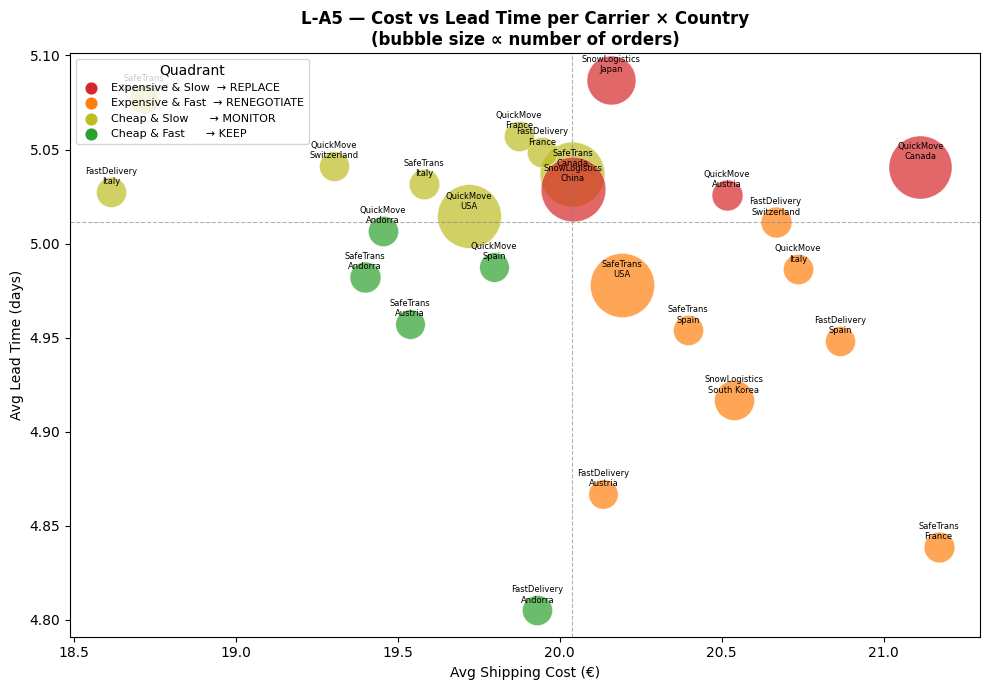

In [15]:
quadrant_colors = {
    "Expensive & Slow  → REPLACE":      "#d62728",
    "Expensive & Fast  → RENEGOTIATE":  "#ff7f0e",
    "Cheap & Slow      → MONITOR":      "#bcbd22",
    "Cheap & Fast      → KEEP":         "#2ca02c",
}

fig, ax = plt.subplots(figsize=(10, 7))

for _, row in la5.iterrows():
    color = quadrant_colors.get(row["Quadrant"], "grey")
    ax.scatter(row["L02_Avg_Cost"], row["L06_Avg_Lead_Time"],
               s=row["N_Orders"] * 0.8, color=color, alpha=0.7, edgecolors="white", linewidths=0.4)
    ax.annotate(f"{row['Shipping_Company']}\n{row['Country']}",
                xy=(row["L02_Avg_Cost"], row["L06_Avg_Lead_Time"]),
                fontsize=6, ha="center", va="bottom",
                xytext=(0, 4), textcoords="offset points")

ax.axvline(median_cost, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.axhline(median_lt,   color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

# legend
for label, color in quadrant_colors.items():
    ax.scatter([], [], color=color, label=label, s=60)
ax.legend(fontsize=8, loc="upper left", title="Quadrant")

ax.set_xlabel("Avg Shipping Cost (€)")
ax.set_ylabel("Avg Lead Time (days)")
ax.set_title("L-A5 — Cost vs Lead Time per Carrier × Country\n(bubble size ∝ number of orders)",
             fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "LA5_leadtime_vs_cost.png", dpi=150, bbox_inches="tight")
plt.show()

la5.to_csv(OUT_DIR / "LA5_leadtime_vs_cost.csv", index=False)

## 9. Bonus — KPIs by Region, Year & Carrier (global roll-ups)

In [16]:
region_kpis  = kpi_table(["Region"])
year_kpis    = kpi_table(["Year"])
carrier_kpis = kpi_table(["Shipping_Company"])

cols_base = ["L01_Shipping_Cost_Total","L02_Avg_Shipping_Cost",
             "L03_Shipping_Cost_Ratio","L04_Net_Margin_Pct","L05_Delta_Margin_pp",
             "L06_Avg_Lead_Time_Days","N_Orders"]

print("── By Region ──")
display(region_kpis[["Region"] + cols_base])

print("── By Year ──")
display(year_kpis[["Year"] + cols_base])

print("── By Carrier (global) ──")
display(carrier_kpis[["Shipping_Company"] + cols_base])

── By Region ──


,Region,L01_Shipping_Cost_Total,L02_Avg_Shipping_Cost,L03_Shipping_Cost_Ratio,L04_Net_Margin_Pct,L05_Delta_Margin_pp,L06_Avg_Lead_Time_Days,N_Orders
0,Asia,"106,830.86",20.17,10.05,35.04,10.05,5.02,5296
1,Europe,"211,130.40",19.93,10.01,34.88,10.01,4.98,10592
2,North America,"214,583.92",20.26,9.97,35.00,9.97,5.02,10592


── By Year ──


,Year,L01_Shipping_Cost_Total,L02_Avg_Shipping_Cost,L03_Shipping_Cost_Ratio,L04_Net_Margin_Pct,L05_Delta_Margin_pp,L06_Avg_Lead_Time_Days,N_Orders
0,2020,"49,596.24",19.80,10.03,35.02,10.03,4.98,2505
1,2021,"62,899.80",20.13,9.97,34.91,9.97,5.02,3125
2,2022,"93,017.06",20.29,10.04,34.97,10.04,5.00,4585
3,2023,"100,695.26",20.12,9.99,34.94,9.99,5.03,5005
4,2024,"107,254.06",19.79,9.99,35.10,9.99,5.01,5420
5,2025,"119,082.76",20.39,9.98,34.84,9.98,4.99,5840


── By Carrier (global) ──


,Shipping_Company,L01_Shipping_Cost_Total,L02_Avg_Shipping_Cost,L03_Shipping_Cost_Ratio,L04_Net_Margin_Pct,L05_Delta_Margin_pp,L06_Avg_Lead_Time_Days,N_Orders
0,FastDelivery,"70,450.65",20.03,10.02,34.97,10.02,4.95,3517
1,QuickMove,"176,883.32",20.22,9.94,35.03,9.94,5.02,8746
2,SafeTrans,"178,380.35",20.00,10.03,34.84,10.03,4.99,8921
3,SnowLogistics,"106,830.86",20.17,10.05,35.04,10.05,5.02,5296


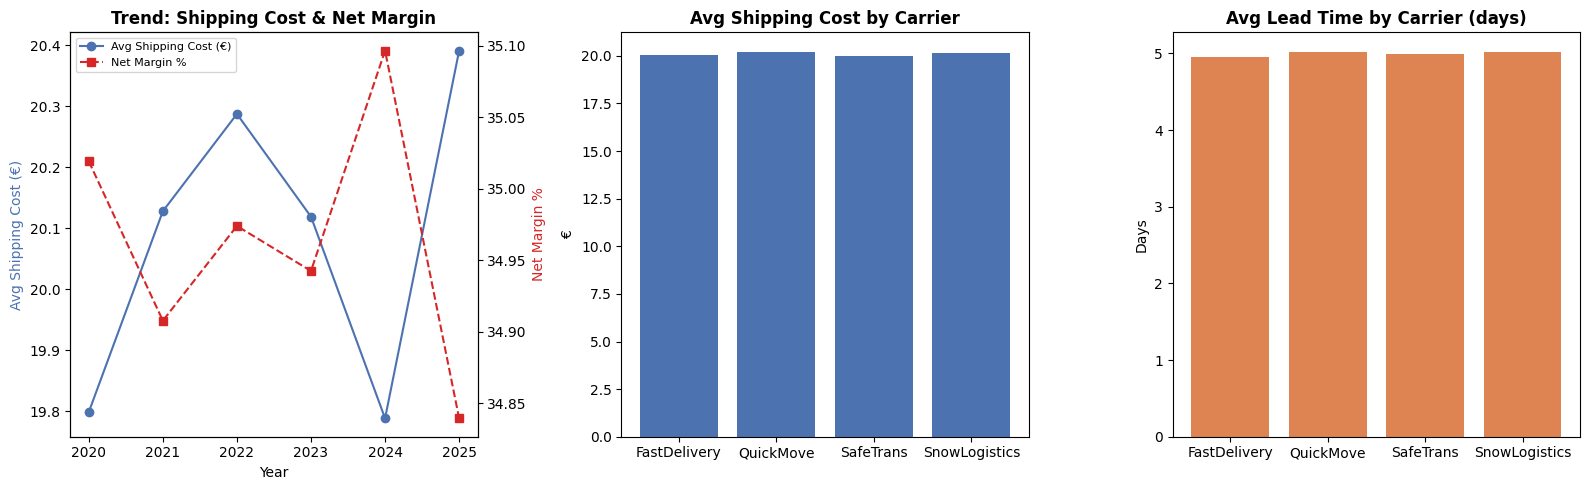


All outputs saved to: /Users/ruimartins/Documents/Hackathons/PWC_Crack_the_data/03. Análise/output_logistics


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# year trend: avg shipping cost & net margin
ax = axes[0]
ax2_twin = ax.twinx()
ax.plot(year_kpis["Year"], year_kpis["L02_Avg_Shipping_Cost"], "o-", color="#4c72b0", label="Avg Shipping Cost (€)")
ax2_twin.plot(year_kpis["Year"], year_kpis["L04_Net_Margin_Pct"], "s--", color="#d62728", label="Net Margin %")
ax.set_xlabel("Year"); ax.set_ylabel("Avg Shipping Cost (€)", color="#4c72b0")
ax2_twin.set_ylabel("Net Margin %", color="#d62728")
ax.set_title("Trend: Shipping Cost & Net Margin", fontweight="bold")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

# carrier: avg cost
ax = axes[1]
ax.bar(carrier_kpis["Shipping_Company"], carrier_kpis["L02_Avg_Shipping_Cost"], color="#4c72b0")
ax.set_title("Avg Shipping Cost by Carrier", fontweight="bold")
ax.set_ylabel("€"); ax.set_xlabel("")

# carrier: avg lead time
ax = axes[2]
ax.bar(carrier_kpis["Shipping_Company"], carrier_kpis["L06_Avg_Lead_Time_Days"], color="#dd8452")
ax.set_title("Avg Lead Time by Carrier (days)", fontweight="bold")
ax.set_ylabel("Days"); ax.set_xlabel("")

plt.tight_layout()
plt.savefig(OUT_DIR / "BONUS_year_region_carrier.png", dpi=150, bbox_inches="tight")
plt.show()

region_kpis.to_csv(OUT_DIR  / "BONUS_region.csv",  index=False)
year_kpis.to_csv(OUT_DIR    / "BONUS_year.csv",     index=False)
carrier_kpis.to_csv(OUT_DIR / "BONUS_carrier.csv",  index=False)
print(f"\nAll outputs saved to: {OUT_DIR}")